In [1]:
import jax
import jax.numpy as jnp
from functools import partial

# --- 1. Neighbor Kernel (Compute Heavy) ---
@jax.jit
def neighbor_kernel(raw_img, thresh, n_min):
    # 1. Threshold
    trigger_mask = raw_img >= thresh
    
    # 2. Convolve / Shift (8 neighbors)
    padded = jnp.pad(trigger_mask, 1, mode='constant')
    n_up    = padded[:-2, 1:-1]
    n_down  = padded[2:, 1:-1]
    n_left  = padded[1:-1, :-2]
    n_right = padded[1:-1, 2:]
    n_ul    = padded[:-2, :-2]
    n_ur    = padded[:-2, 2:]
    n_dl    = padded[2:, :-2]
    n_dr    = padded[2:, 2:]
    
    has_neighbor = (n_up | n_down | n_left | n_right | n_ul | n_ur | n_dl | n_dr)
    
    # 3. Decision
    supported_mask = trigger_mask & has_neighbor
    n_supported = jnp.sum(supported_mask)
    return n_supported >= n_min, supported_mask

# --- 2. Threshold Kernel (Memory Bound, Light Compute) ---
@jax.jit
def threshold_kernel(raw_img, thresh, n_min):
    # Simple check: Is the image interesting?
    # (Imitating a simple trigger that just counts pixels)
    trigger_mask = raw_img >= thresh
    count = jnp.sum(trigger_mask)
    return count >= n_min, trigger_mask

KERNELS = {
    'Neighbor': neighbor_kernel,
    'Threshold': threshold_kernel
}

In [2]:
import time
import pandas as pd
import numpy as np
import jax
import jax.numpy as jnp
from functools import partial
from panoseti_interface import PanosetiRun
from jax_filters import KERNELS

# --- CONFIGURATION ---
run_dir = "data/obs_Palomar.start_2026-02-09T09_46_29Z.runtype_obs-test.pffd"

# Benchmark Parameters
BATCH_SIZES = 2**np.arange(20)
PARAMS = {'thresh': 150, 'n_min': 3}
N_REPEATS = 30        # repeats per config
TEST_DURATION = 1  # seconds per repeat

# Load Data
print(f"Loading Run: {run_dir}...")
run = PanosetiRun(run_dir)
prods = [p for p in run.list_products() if 'ph256' in p]
if not prods: raise ValueError("No ph256 data found")
seq = run.get_product(prods[0])
SEQ_LEN = len(seq)

results = []
kernel_name = 'Neighbor'
kernel_func = KERNELS['neighbor']

print(f"Running Benchmark ({N_REPEATS} repeats per configuration)...")
print(f"{'Batch':<6} | {'Run':<4} | {'kFPS':<10}")
print("-" * 35)

for b_size in BATCH_SIZES:
    # 1. Compile Vmap for this batch size
    vmapped = jax.jit(jax.vmap(partial(kernel_func, **PARAMS)))
    
    # Warmup
    dummy = jnp.zeros((b_size, 16, 16), dtype=jnp.int16)
    res = vmapped(dummy)
    if isinstance(res, (tuple, list)): res[-1].block_until_ready()
    else: res.block_until_ready()
    
    # 2. Statistical Repeats
    for i in range(N_REPEATS):
        processed = 0
        cursor = 0
        
        loop_start = time.perf_counter()
        while (time.perf_counter() - loop_start) < TEST_DURATION:
            
            # --- Cyclic Ring Access Logic ---
            remaining = SEQ_LEN - cursor
            if remaining >= b_size:
                chunk = seq.get_image_array(cursor, b_size)
                cursor += b_size
                if cursor == SEQ_LEN: cursor = 0
            else:
                # Wrap-around stitching
                part1 = seq.get_image_array(cursor, remaining)
                part2 = seq.get_image_array(0, b_size - remaining)
                chunk = np.concatenate([part1, part2])
                cursor = b_size - remaining
            # -------------------------------
                
            jax_chunk = jnp.array(chunk)
            res = vmapped(jax_chunk)
            if isinstance(res, (tuple, list)): res[-1].block_until_ready()
            else: res.block_until_ready()
            
            processed += b_size
            
            # Break early for tiny batches to avoid infinite loop overhead
            if processed > 5000 and b_size < 32: break
            
        dt = time.perf_counter() - loop_start
        
        # Metrics
        fps = processed / dt
        kfps = fps / 1000.0
        latency_ms = (dt / processed) * b_size * 1000
        
        print(f"{b_size:<6} | {i+1}/{N_REPEATS} | {kfps:,.0f} k")
        
        results.append({
            'Kernel': kernel_name,
            'Batch Size': b_size,
            'Repeat': i,
            'kFPS': kfps,
            'Latency per Batch (ms)': latency_ms,
        })

df_stats = pd.DataFrame(results)
print("\nBenchmark Complete.")

Loading Run: data/obs_Palomar.start_2026-02-09T09_46_29Z.runtype_obs-test.pffd...
Running Benchmark (30 repeats per configuration)...
Batch  | Run  | kFPS      
-----------------------------------
1      | 1/30 | 14 k
1      | 2/30 | 14 k
1      | 3/30 | 14 k
1      | 4/30 | 15 k
1      | 5/30 | 15 k
1      | 6/30 | 14 k
1      | 7/30 | 14 k
1      | 8/30 | 14 k
1      | 9/30 | 15 k
1      | 10/30 | 14 k
1      | 11/30 | 15 k
1      | 12/30 | 15 k
1      | 13/30 | 13 k
1      | 14/30 | 8 k
1      | 15/30 | 15 k
1      | 16/30 | 15 k
1      | 17/30 | 15 k
1      | 18/30 | 15 k
1      | 19/30 | 15 k
1      | 20/30 | 15 k
1      | 21/30 | 15 k
1      | 22/30 | 15 k
1      | 23/30 | 15 k
1      | 24/30 | 15 k
1      | 25/30 | 15 k
1      | 26/30 | 15 k
1      | 27/30 | 14 k
1      | 28/30 | 15 k
1      | 29/30 | 15 k
1      | 30/30 | 15 k
2      | 1/30 | 29 k
2      | 2/30 | 29 k
2      | 3/30 | 29 k
2      | 4/30 | 29 k
2      | 5/30 | 31 k
2      | 6/30 | 30 k
2      | 7/30 | 30 k
2     

In [6]:
df_stats.to_csv('benchmark_stats.csv')

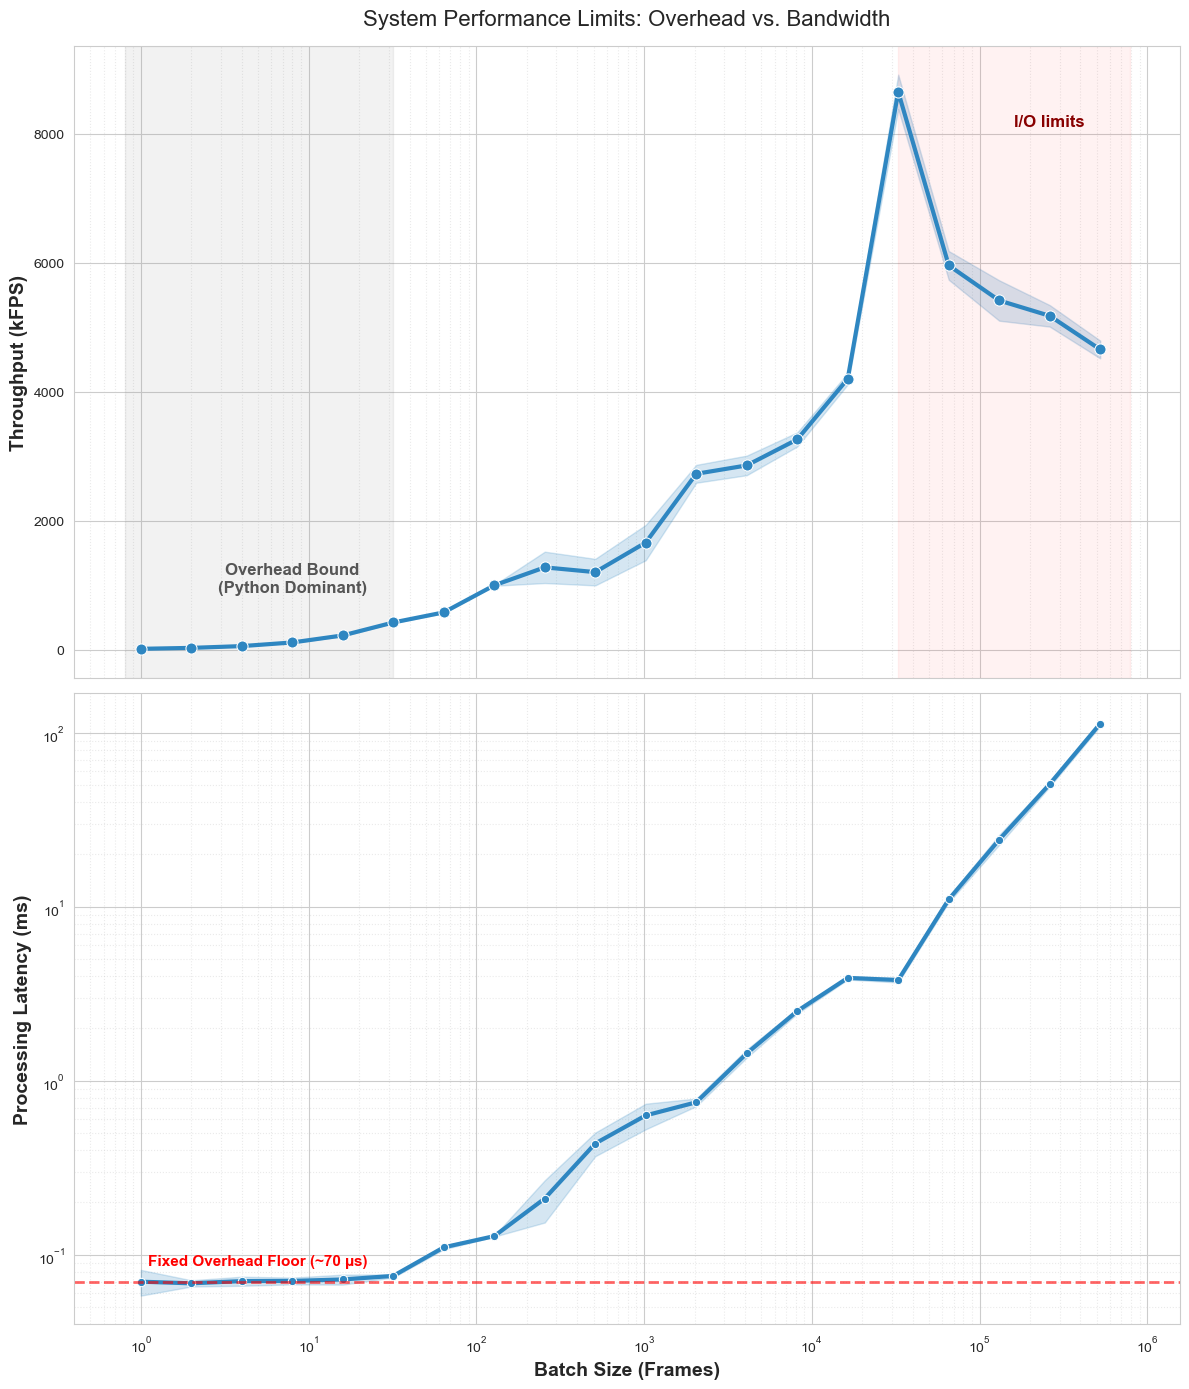

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

# Setup
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14), sharex=True)
sns.set_style("whitegrid")
color = "#2E86C1" # Professional Blue

# === PLOT 1: Throughput (kFPS) ===
sns.lineplot(data=df_stats, x='Batch Size', y='kFPS', 
             marker='o', markersize=8, linewidth=3, ax=ax1, color=color,
             errorbar='sd', err_style='band')

# --- Region 1: Overhead Bound (Small Batches) ---
# FPS grows linearly because we are just amortizing fixed Python cost
ax1.axvspan(0.8, 32, color='gray', alpha=0.1)
ax1.text(8, df_stats['kFPS'].max() * 0.1, "Overhead Bound\n(Python Dominant)", 
         ha='center', fontsize=12, fontweight='bold', color='#555')

# --- Region 2: I/O Saturation (Large Batches) ---
# FPS plateaus because we hit the M1 Max memory bandwidth limit
ax1.axvspan(2**15, BATCH_SIZES[-1] * 1.5, color='red', alpha=0.05)
ax1.text(2**18, df_stats['kFPS'].max() * 0.9, "I/O limits", 
         ha='center', fontsize=12, fontweight='bold', color='#800')

# Formatting
ax1.set_xscale('log')
ax1.set_xlabel("Batch Size (Frames)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Throughput (kFPS)", fontsize=14, fontweight='bold')
ax1.set_title("System Performance Limits: Overhead vs. Bandwidth", fontsize=16, pad=15)
ax1.grid(True, which="minor", ls=":", alpha=0.4)


# === PLOT 2: Latency Cost ===
sns.lineplot(data=df_stats, x='Batch Size', y='Latency per Batch (ms)', 
             marker='o', linewidth=3, ax=ax2, color=color, legend=False,
             errorbar='sd', err_style='band')

# Python Floor Annotation
floor_val = df_stats[df_stats['Batch Size']==1]['Latency per Batch (ms)'].mean()
ax2.axhline(floor_val, color='red', linestyle='--', alpha=0.6, linewidth=2)
ax2.text(1.1, floor_val*1.2, f"Fixed Overhead Floor (~{floor_val*1000:.0f} µs)", 
         color='red', fontsize=11, fontweight='bold', va='bottom')

# Bandwidth Linear Scaling
# In the saturation region, latency scales linearly with data size
# ax2.text(16384, 1, "Linear Scaling\n(Data Dependent)", 
         # ha='center', fontsize=11, color='#555', fontweight='bold', rotation=35)

# Formatting
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel("Batch Size (Frames)", fontsize=14, fontweight='bold')
ax2.set_ylabel("Processing Latency (ms)", fontsize=14, fontweight='bold')
ax2.grid(True, which="minor", ls=":", alpha=0.4)

plt.tight_layout()
plt.show()

In [20]:
import jax
import jax.numpy as jnp
from jax_filters import KERNELS  # Assuming your kernels are here

# 1. Setup Single Frame
# We analyze a single frame to get the atomic unit of work
shape = (32, 32)
dtype = jnp.int16
dummy_img = jnp.zeros(shape, dtype=dtype)
params = {'thresh': 150, 'n_min': 3}
kernel = KERNELS['neighbor'] # or 'Neighbor' depending on your dict key

# 2. Compile and Analyze
# We lower the function to HLO (High Level Operations) to inspect costs
lowered = jax.jit(lambda x: kernel(x, **params)).lower(dummy_img)
compiled = lowered.compile()

# 3. Extract Metrics
cost = compiled.cost_analysis()

print(f"JAX kernel compute demand per frame: {shape}, {dtype}")
print(f"FLOPs (Float Ops):   {cost.get('flops', 0):,.0f}") 
# Note: XLA often counts integer comparisons/logic as 'transcendentals' or just 'ops'
# depending on the backend, but 'bytes accessed' is usually accurate.
print(f"Bytes Accessed:      {cost.get('bytes accessed', 0):,.0f}")
print(f"Arithmetic Intensity: {cost.get('flops', 0) / cost.get('bytes accessed', 1):.3f} ops/byte")

JAX kernel compute demand per frame: (32, 32), <class 'jax.numpy.int16'>
FLOPs (Float Ops):   16,383
Bytes Accessed:      20,669
Arithmetic Intensity: 0.793 ops/byte
